# MLE over time, v6: one beam for light shift, decoherence and readout (`data_mle_over_time_onebeam_1`)

One-beam counterpart of `multiparameter_plots_v5.ipynb`. Data from
`multiparameter_trotter_v6_decoherence_least_squares_over_time.py` run on the cluster with
`--eta 30 --od 10`: the off-resonant probe that produces the tensor shift $\beta J_z^2$ is also the
beam that scatters (spin-flip channel $L_\pm=\sqrt{\gamma}\,J_\pm$) and the beam that is read out
(Faraday rotation with photon shot noise). The probe strength is one knob, so per $\beta$ the run
derives (see `latex/open_system_model.tex`, section "One beam")

$$\gamma = \beta/\eta, \qquad \sigma = \sqrt{\eta/(\mathrm{OD}_{\rm eff}\,N_a\,\delta t\,\beta)} .$$

A stronger probe brings more nonlinearity, more decoherence and less shot noise. There is no
$\beta=0$ reference any more: no light is no measurement. The old v4/v5 noise level
$\sigma = 0.021$ corresponds to $\beta\approx 33$ here.

Run parameters (from `parameters.txt`): $J=3$, observable $J_y$, $\beta\in\{0.5, 1, 2, 5, 10, 20\}$,
$\eta = 30$, $\mathrm{OD}_{\rm eff} = 10$, $N_a = 2\times10^5$, $T = 14/\Omega$, 300 fits per
($\beta$, cutoff), one $w_{\rm true}$ draw per `task_N` folder (all 20 array tasks). Paths are
relative to the repo root. $\eta$ and $\mathrm{OD}_{\rm eff}$ are placeholders of the right order.

The cost floor and the $5\sigma$ band are now per $\beta$ (`sn_sd_array.npy`, and
`cost_floor.npy` has shape `(n_beta, n_time)`); the cost-band filtering and the average over
tasks are done in this notebook as in v5.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
%matplotlib inline

DATA_ROOT = Path("data_mle_over_time_onebeam_1")

def load_npy(root_folder):
    '''Load every .npy under root_folder into a dict keyed by filename stem.'''
    root = Path(root_folder)
    return {file.stem: np.load(file) for file in root.rglob("*.npy")}

def task_dirs(root=DATA_ROOT):
    return sorted((p for p in root.iterdir() if p.is_dir() and p.name.startswith("task_")),
                  key=lambda p: int(p.name.split("_")[1]))

labels_omega = [r'$\omega_x$', r'$\omega_y$', r'$\omega_z$']
beta_colors = ['#2a78d6', '#1baf7a', '#eda100', '#e34948', '#008300', '#4a3aa7', '#e87ba4', '#eb6834']
dt = 1e-3
n_fits = 300

#Shot-noise cost floor: the residuals at w_true equal the injected noise, so
#E[cost at truth] = 0.5*n_sub*sn_sd^2. Fits whose cost leaves the 5-sigma
#chi-square band converged to a local minimum, not to the global one. In the
#one-beam model sn_sd is per beta (sn_sd_array.npy), so floor and band are (n_beta, n_time).
t_steps_run = 14000

def cost_floor_and_band(checkpoint_times, sn_sd_array, k=5.0):
    n_sub = np.array([np.sum(np.linspace(0, t_steps_run, t_steps_run, dtype=int) <= tc) for tc in checkpoint_times])
    sd2 = np.asarray(sn_sd_array)[:, None]**2
    cost_floor = 0.5 * sd2 * n_sub[None, :]
    cost_band = 0.5 * sd2 * (n_sub + k*np.sqrt(2*n_sub))[None, :]
    return cost_floor, cost_band

def beta_label(run, b_idx):
    '''Legend label carrying beta and the decoherence rate and shot noise it implies.'''
    beta, gamma, sd = run['beta_array'][b_idx], run['gamma_array'][b_idx], run['sn_sd_array'][b_idx]
    return fr'$\beta={beta:g}$, $\gamma={gamma:.3g}$, $\sigma={sd:.3g}$'

def filter_cost_band(run):
    '''Same rule as filter_cost_band_mle_over_time.py: fits whose cost exceeds the 5-sigma band
    are set to NaN (shape preserved) and bias/variance are recomputed from the survivors.
    Returns bias (1, n_beta, n_time, 3), variance (same), removed fraction (1, n_beta, n_time).'''
    _, band = cost_floor_and_band(run['time_cutoffs_array'], run['sn_sd_array'])   # (n_beta, n_time)
    mask_bad = run['cost_est'] > band[None, :, :, None]
    w_f = np.where(mask_bad[..., None], np.nan, run['w_est'])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=RuntimeWarning)
        bias = np.nanmean(w_f, axis=3) - run['w_true'][:, None, None, :]
        variance = np.nanvar(w_f, axis=3, ddof=1)
    return bias, variance, mask_bad.mean(axis=-1)

def crb_diag(run):
    '''Diagonal of the inverse (realization-averaged) Fisher matrix, shape (1, n_beta, n_time, 3).'''
    return np.diagonal(np.linalg.inv(run['fisher']), axis1=-2, axis2=-1)

print("tasks found:", [p.name for p in task_dirs()])


tasks found: ['task_0', 'task_1', 'task_2', 'task_3', 'task_4', 'task_5', 'task_6', 'task_7', 'task_8', 'task_9', 'task_10', 'task_11', 'task_12', 'task_13', 'task_14', 'task_15', 'task_16', 'task_17', 'task_18', 'task_19']


## Single task (raw statistics, v4 style)

Same panels as the v4 notebook for one `task_N` folder: variance and |bias| of the 300 fits at every
cutoff, least-squares cost with the noise floor and $5\sigma$ band, trace of the inverse Fisher
information (the Cramér–Rao bound on the total variance), and the eigenvalues of
$\mathrm{Cov} - F^{-1}$. The chi-square acceptance fraction is added as a QA panel. Note the raw
variance is dominated by the ~5–10 % of fits that converged to a local minimum; the filtered
statistics below are the meaningful ones.


task_0 w_true = [ 0.01257302 -0.01321049  0.06404227]


,gamma,sn_sd,1/gamma (Omega t),gamma*T
beta,,,,
0.5,0.0167,0.1732,60.0,0.2333
1.0,0.0333,0.1225,30.0,0.4667
2.0,0.0667,0.0866,15.0,0.9333
5.0,0.1667,0.0548,6.0,2.3333
10.0,0.3333,0.0387,3.0,4.6667
20.0,0.6667,0.0274,1.5,9.3333


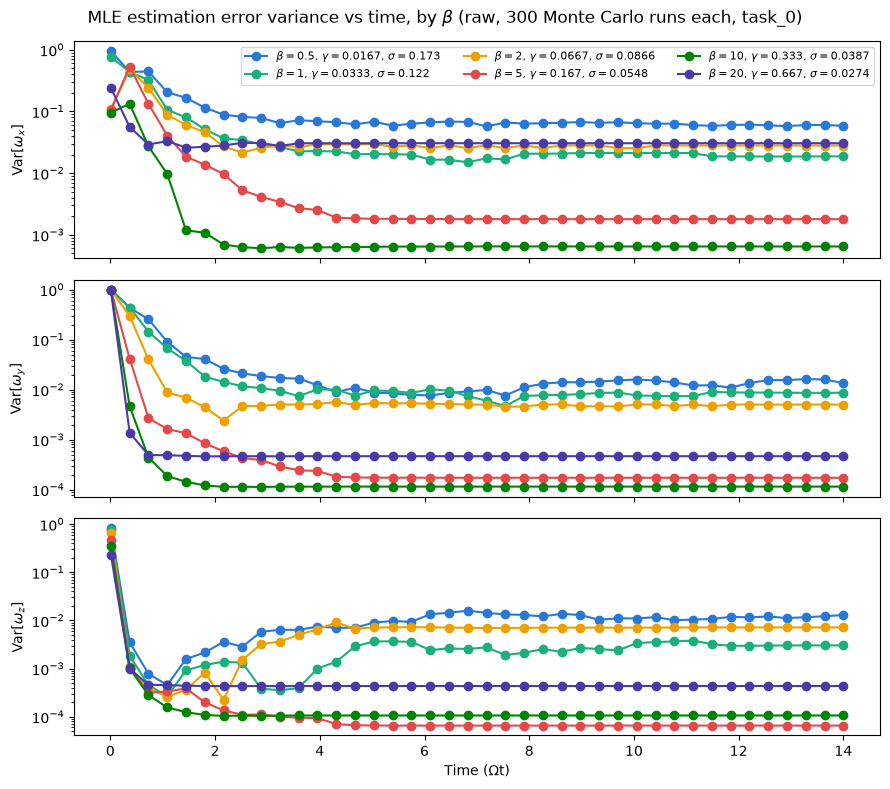

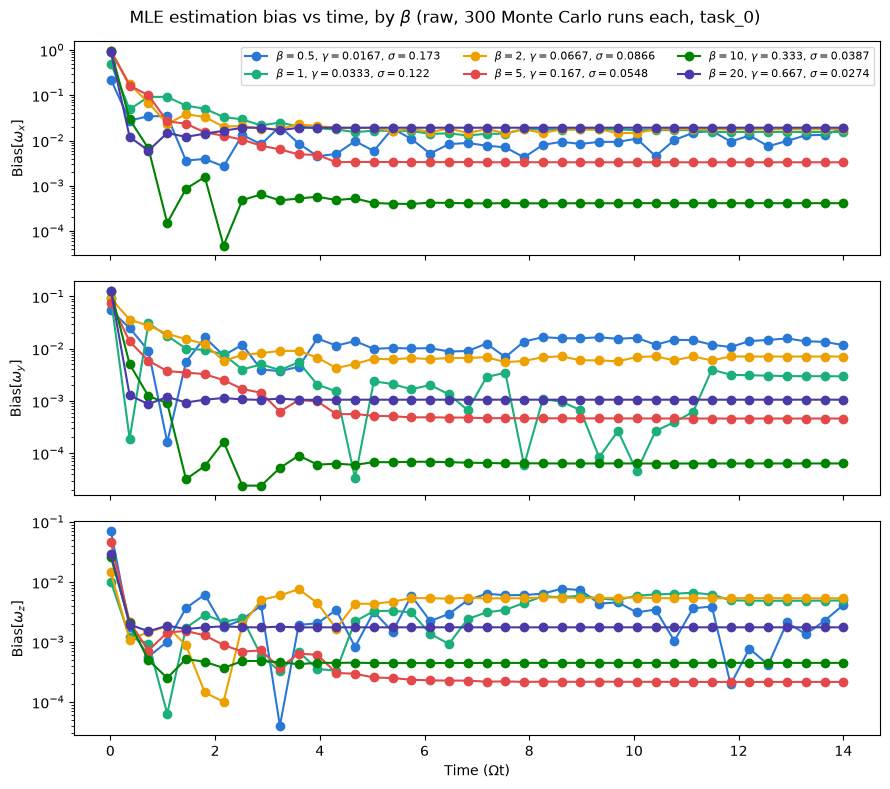

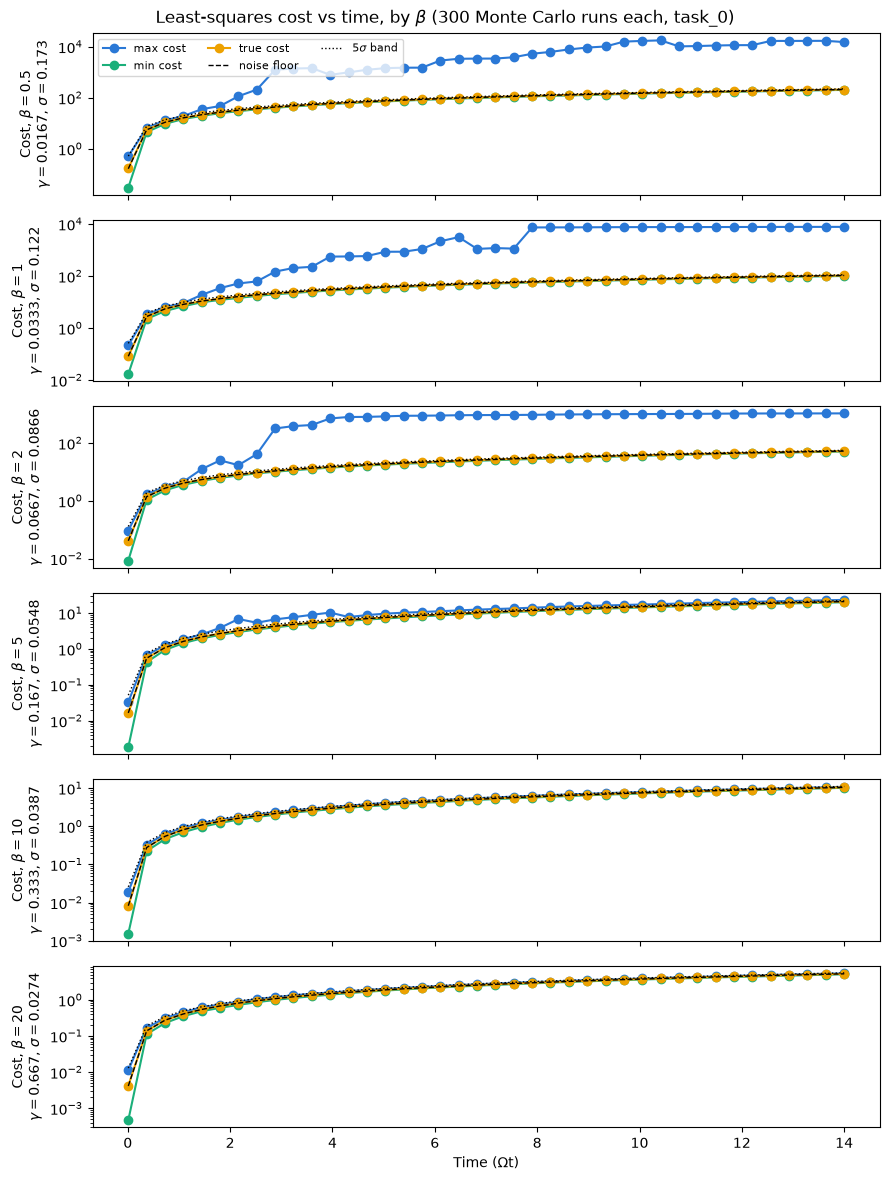

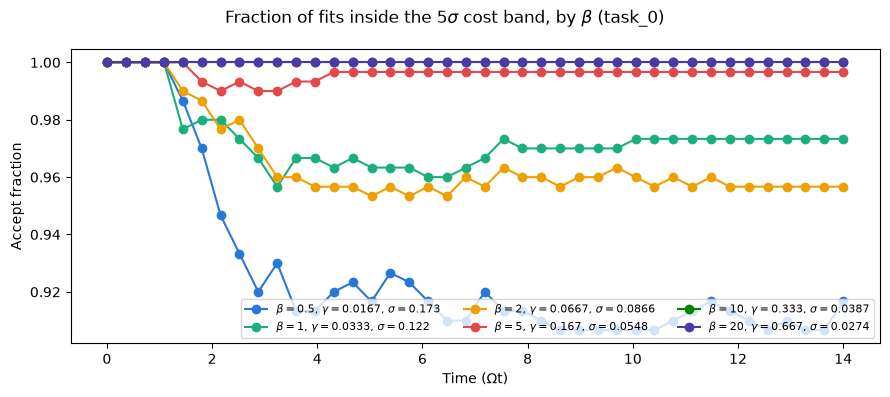

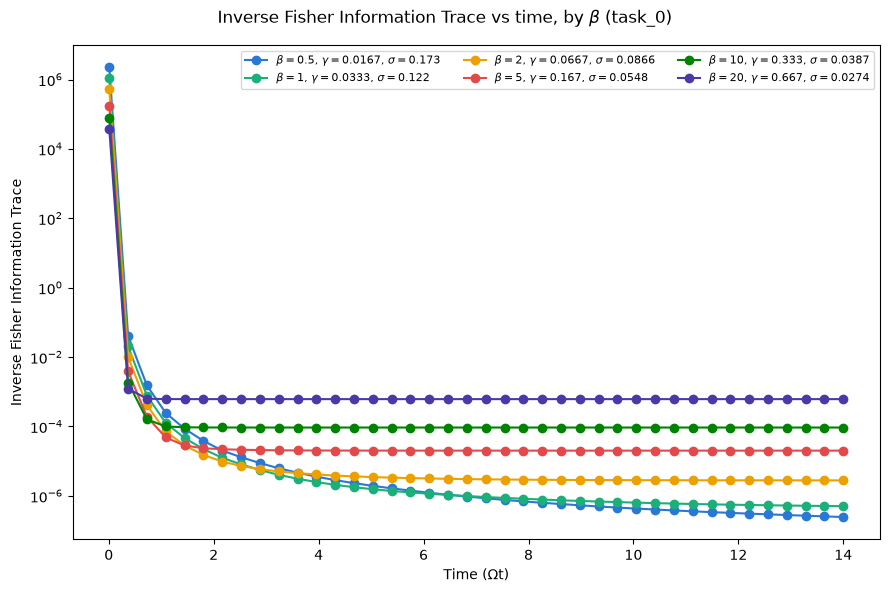

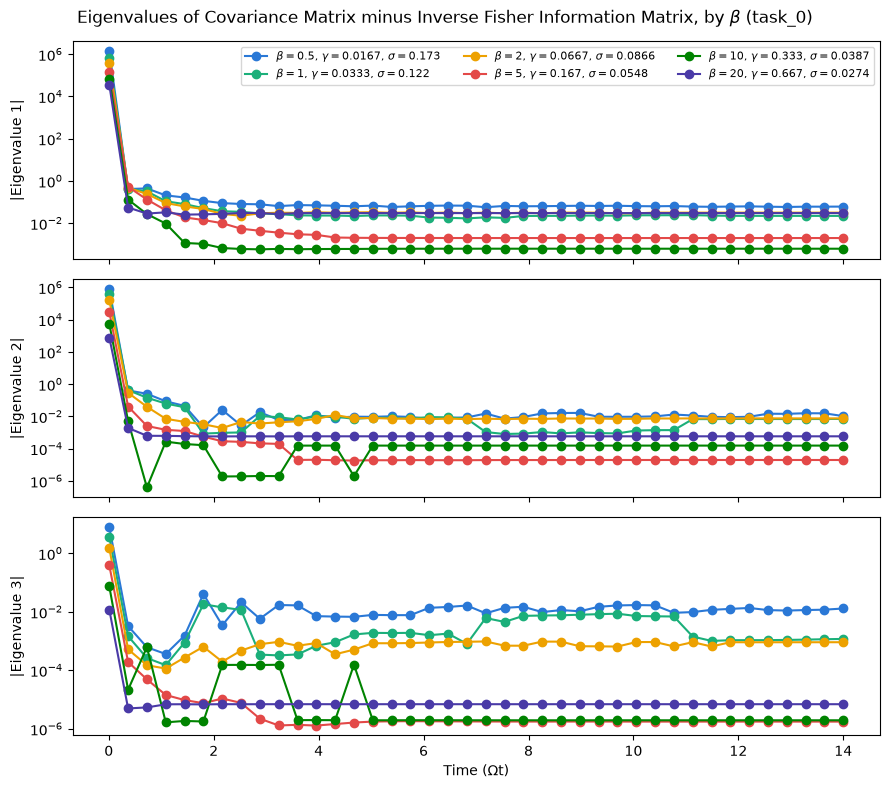

In [2]:
TASK = "task_0"
mle_over_time = load_npy(DATA_ROOT / TASK)
beta_values = mle_over_time['beta_array']
gamma_values = mle_over_time['gamma_array']
sn_values = mle_over_time['sn_sd_array']
checkpoint_times = mle_over_time['time_cutoffs_array']
omega_true = mle_over_time['w_true']
cost_floor, cost_band = cost_floor_and_band(checkpoint_times, sn_values)   # (n_beta, n_time)
assert np.allclose(cost_floor, mle_over_time['cost_floor']), "notebook cost model disagrees with the run's cost_floor.npy"
print(TASK, "w_true =", omega_true[0])
display(pd.DataFrame({'gamma': gamma_values, 'sn_sd': sn_values, '1/gamma (Omega t)': 1/gamma_values,
                      'gamma*T': gamma_values*checkpoint_times[-1]*dt}, index=pd.Index(beta_values, name='beta')).round(4))

#Plot variance of MLE estimation error over time for different beta values
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j, lab in enumerate(labels_omega):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, mle_over_time['std_array'][0][b_idx][:, j], 'o-',
                         color=color, label=beta_label(mle_over_time, b_idx))
    axes[j].set_ylabel(f'Var[{lab}]')
axes[0].legend(loc='upper right', ncol=3, fontsize=8)
axes[-1].set_xlabel(r'Time ($\Omega$t)')
fig.suptitle(f'MLE estimation error variance vs time, by $\\beta$ (raw, {n_fits} Monte Carlo runs each, {TASK})')
plt.tight_layout()
plt.show()

#Plot bias of MLE estimation error over time for different beta values
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j, lab in enumerate(labels_omega):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, np.abs(mle_over_time['bias'][0][b_idx][:, j]), 'o-',
                         color=color, label=beta_label(mle_over_time, b_idx))
    axes[j].set_ylabel(f'Bias[{lab}]')
axes[0].legend(loc='upper right', ncol=3, fontsize=8)
axes[-1].set_xlabel(r'Time ($\Omega$t)')
fig.suptitle(f'MLE estimation bias vs time, by $\\beta$ (raw, {n_fits} Monte Carlo runs each, {TASK})')
plt.tight_layout()
plt.show()

#Plot least-squares cost of the kept fits over time for different beta values
#(cost_true is saved as 0.5*||residuals||^2 already; no extra 0.5 factor here)
fig, axes = plt.subplots(len(beta_values), 1, figsize=(9, 12), sharex=True)
for b_idx, beta in enumerate(beta_values):
    axes[b_idx].semilogy(checkpoint_times*dt, mle_over_time['max_cost_estimate'][0][b_idx], 'o-',
                         color=beta_colors[0], label='max cost')
    axes[b_idx].semilogy(checkpoint_times*dt, mle_over_time['min_cost_estimate'][0][b_idx], 'o-',
                         color=beta_colors[1], label='min cost')
    axes[b_idx].semilogy(checkpoint_times*dt, mle_over_time['cost_true'][0][b_idx], 'o-',
                         color=beta_colors[2], label='true cost')
    axes[b_idx].semilogy(checkpoint_times*dt, cost_floor[b_idx], 'k--', lw=1, label='noise floor')
    axes[b_idx].semilogy(checkpoint_times*dt, cost_band[b_idx], 'k:', lw=1, label=r'$5\sigma$ band')
    axes[b_idx].set_ylabel(f'Cost, $\\beta={beta:g}$\n$\\gamma={gamma_values[b_idx]:.3g}$, $\\sigma={sn_values[b_idx]:.3g}$')
axes[0].legend(loc='upper left', ncol=3, fontsize=8)
axes[-1].set_xlabel(r'Time ($\Omega$t)')
fig.suptitle(f'Least-squares cost vs time, by $\\beta$ ({n_fits} Monte Carlo runs each, {TASK})')
plt.tight_layout()
plt.show()

#Chi-square acceptance fraction (QA): fraction of the 300 fits inside the 5-sigma band
fig, ax = plt.subplots(1, 1, figsize=(9, 4))
for b_idx, beta in enumerate(beta_values):
    ax.plot(checkpoint_times*dt, mle_over_time['accept_fraction'][0][b_idx], 'o-',
            color=beta_colors[b_idx % len(beta_colors)], label=beta_label(mle_over_time, b_idx))
ax.set_ylabel('Accept fraction')
ax.set_xlabel(r'Time ($\Omega$t)')
ax.legend(loc='lower right', ncol=3, fontsize=8)
fig.suptitle(f'Fraction of fits inside the $5\\sigma$ cost band, by $\\beta$ ({TASK})')
plt.tight_layout()
plt.show()

#Plot Trace of inverse Fisher Information over time for different beta values
fig, ax = plt.subplots(1, 1, figsize=(9, 6))
for b_idx, beta in enumerate(beta_values):
    ax.semilogy(checkpoint_times*dt, mle_over_time['fisher_inv_trace'][0][b_idx], 'o-',
                color=beta_colors[b_idx % len(beta_colors)], label=beta_label(mle_over_time, b_idx))
ax.set_ylabel('Inverse Fisher Information Trace')
ax.set_xlabel(r'Time ($\Omega$t)')
ax.legend(loc='upper right', ncol=3, fontsize=8)
fig.suptitle(f'Inverse Fisher Information Trace vs time, by $\\beta$ ({TASK})')
plt.tight_layout()
plt.show()

#Eigenvalues of Covariance minus inverse Fisher matrix
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j in range(3):
    for b_idx, beta in enumerate(beta_values):
        axes[j].semilogy(checkpoint_times*dt, np.abs(mle_over_time['CRB_diff_eig'][0][b_idx][:, j]), 'o-',
                         color=beta_colors[b_idx % len(beta_colors)], label=beta_label(mle_over_time, b_idx))
    axes[j].set_ylabel(f'|Eigenvalue {j+1}|')
axes[0].legend(loc='upper right', ncol=3, fontsize=8)
axes[-1].set_xlabel(r'Time ($\Omega$t)')
fig.suptitle(f'Eigenvalues of Covariance Matrix minus Inverse Fisher Information Matrix, by $\\beta$ ({TASK})')
plt.tight_layout()
plt.show()


### Cost histograms

Distribution of the least-squares cost of the 300 fits at a chosen $\beta$ and cutoff, with the noise
floor and the $5\sigma$ band. Fits to the right of the band are the local-minimum failures that the
filtering below removes.


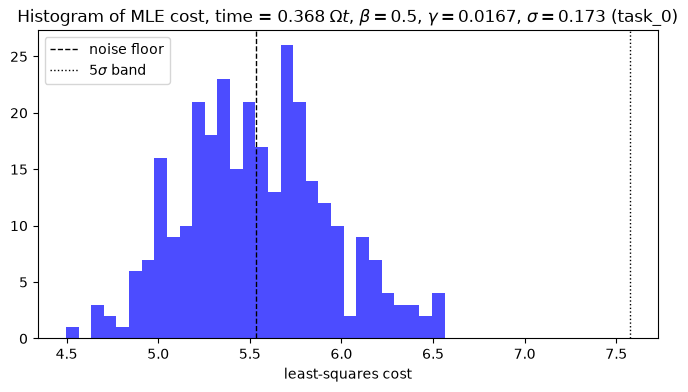

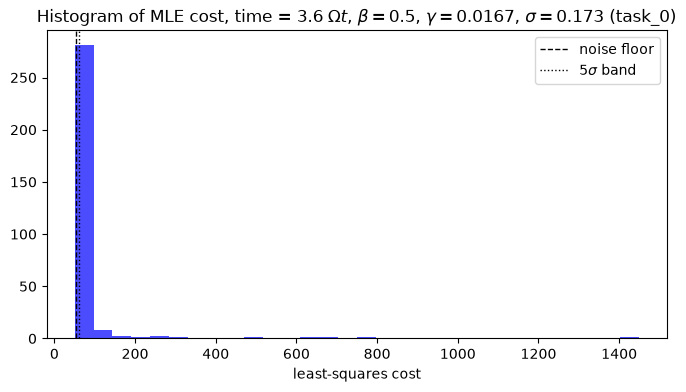

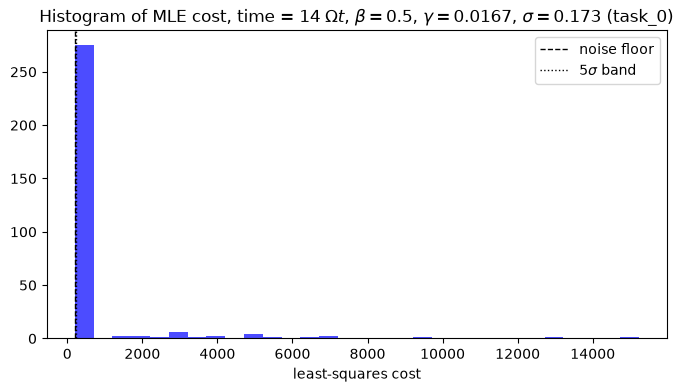

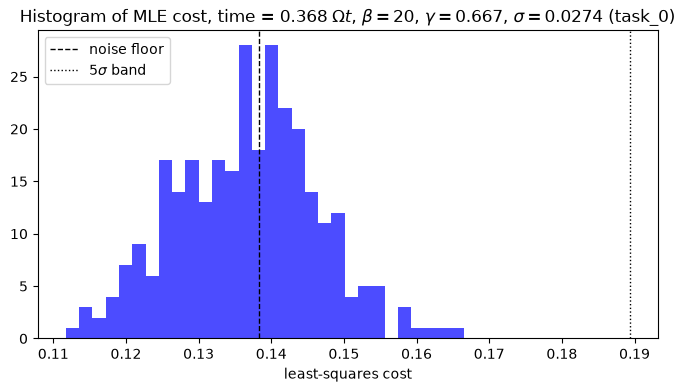

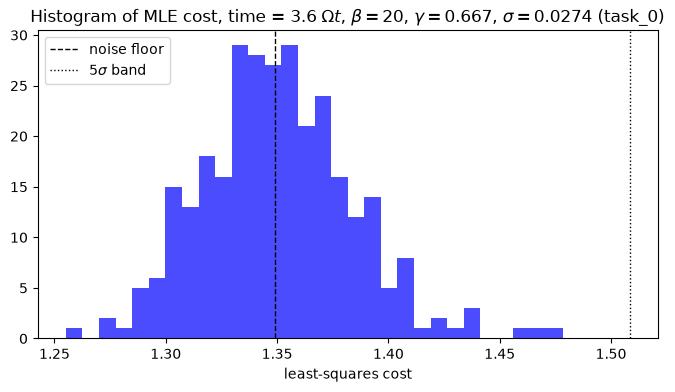

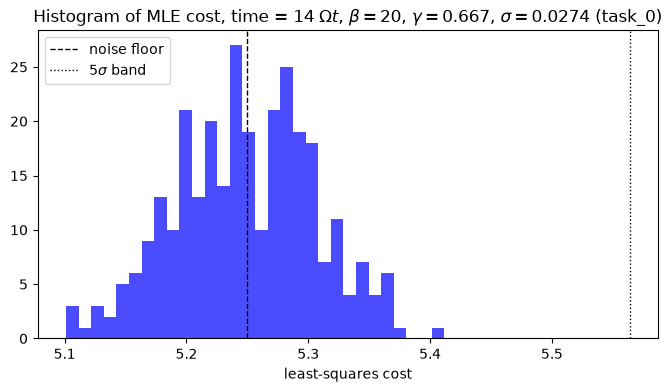

In [3]:
cost_est = mle_over_time['cost_est']      # (1, n_beta, n_time, n_fits)
for beta_index in [0, len(beta_values) - 1]:
    for time_index in [1, 10, len(checkpoint_times) - 1]:
        plt.figure(figsize=(8, 4))
        plt.hist(cost_est[0, beta_index, time_index, :], bins=30, density=False, alpha=0.7, color='blue')
        plt.axvline(cost_floor[beta_index, time_index], color='k', ls='--', lw=1, label='noise floor')
        plt.axvline(cost_band[beta_index, time_index], color='k', ls=':', lw=1, label=r'$5\sigma$ band')
        plt.title(f'Histogram of MLE cost, time = ${checkpoint_times[time_index]*dt:.3g}\\;\\Omega t$, '
                  f'$\\beta = {beta_values[beta_index]:g}$, $\\gamma = {gamma_values[beta_index]:.3g}$, $\\sigma = {sn_values[beta_index]:.3g}$ ({TASK})')
        plt.xlabel('least-squares cost')
        plt.legend()
        plt.show()


## Single task, cost-band filtered, against the Cramér–Rao bound

Fits above the $5\sigma$ band are dropped (same rule as `filter_cost_band_mle_over_time.py`) and the
variance and bias are recomputed from the survivors. The dashed lines are the diagonal of the
realization-averaged $F^{-1}$: the Cramér–Rao bound for each parameter. There is no closed-system
reference in the one-beam model: every $\beta$ decoheres at $\gamma=\beta/\eta$ and is read out with
shot noise $\sigma\propto\beta^{-1/2}$. Weak probes start high (large $\sigma$) but keep falling;
strong probes fall fast but saturate on the scale $1/\gamma$.


task_0: removed fraction per beta (max over cutoffs): [0.093 0.043 0.047 0.01  0.    0.   ]


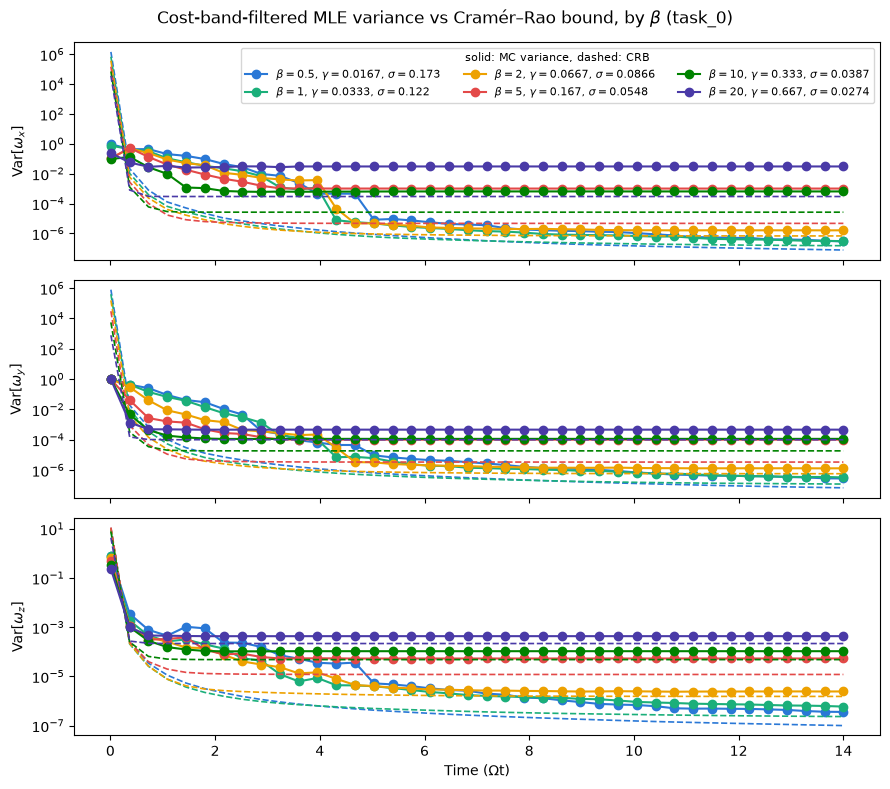

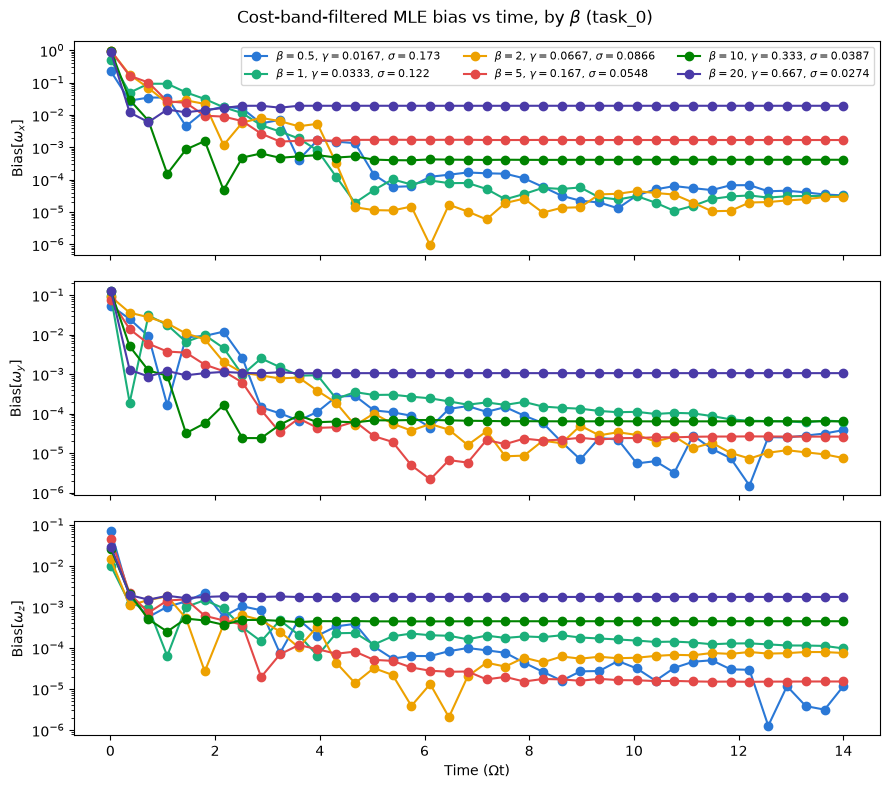

In [4]:
bias_f, var_f, removed_f = filter_cost_band(mle_over_time)
crb = crb_diag(mle_over_time)
print(f"{TASK}: removed fraction per beta (max over cutoffs):", np.round(removed_f[0].max(axis=1), 3))

#Filtered variance vs the Cramer-Rao bound, per parameter
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j, lab in enumerate(labels_omega):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, var_f[0][b_idx][:, j], 'o-', color=color, label=beta_label(mle_over_time, b_idx))
        axes[j].semilogy(checkpoint_times*dt, crb[0][b_idx][:, j], '--', color=color, lw=1.2)
    axes[j].set_ylabel(f'Var[{lab}]')
axes[0].legend(loc='upper right', ncol=3, fontsize=8, title='solid: MC variance, dashed: CRB', title_fontsize=8)
axes[-1].set_xlabel(r'Time ($\Omega$t)')
fig.suptitle(f'Cost-band-filtered MLE variance vs Cramér–Rao bound, by $\\beta$ ({TASK})')
plt.tight_layout()
plt.show()

#Filtered bias
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j, lab in enumerate(labels_omega):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, np.abs(bias_f[0][b_idx][:, j]), 'o-', color=color, label=beta_label(mle_over_time, b_idx))
    axes[j].set_ylabel(f'Bias[{lab}]')
axes[0].legend(loc='upper right', ncol=3, fontsize=8)
axes[-1].set_xlabel(r'Time ($\Omega$t)')
fig.suptitle(f'Cost-band-filtered MLE bias vs time, by $\\beta$ ({TASK})')
plt.tight_layout()
plt.show()


## Average over all tasks (cost-band filtered)

Every `task_N` is an independent $w_{\rm true}$ draw. Per task the filtered bias, variance and
$F^{-1}$ are computed as above, then averaged over tasks (this is what `filtered_avg/` held for
runs 12 and benchmark 1).


20 tasks; w_true spread (std over tasks): [0.098 0.123 0.107]
worst accept fraction per task: {'task_0': 0.907, 'task_1': 0.9, 'task_2': 0.883, 'task_3': 0.887, 'task_4': 0.917, 'task_5': 0.887, 'task_6': 0.93, 'task_7': 0.907, 'task_8': 0.89, 'task_9': 0.94, 'task_10': 0.907, 'task_11': 0.877, 'task_12': 0.89, 'task_13': 0.903, 'task_14': 0.887, 'task_15': 0.91, 'task_16': 0.897, 'task_17': 0.86, 'task_18': 0.873, 'task_19': 0.9}


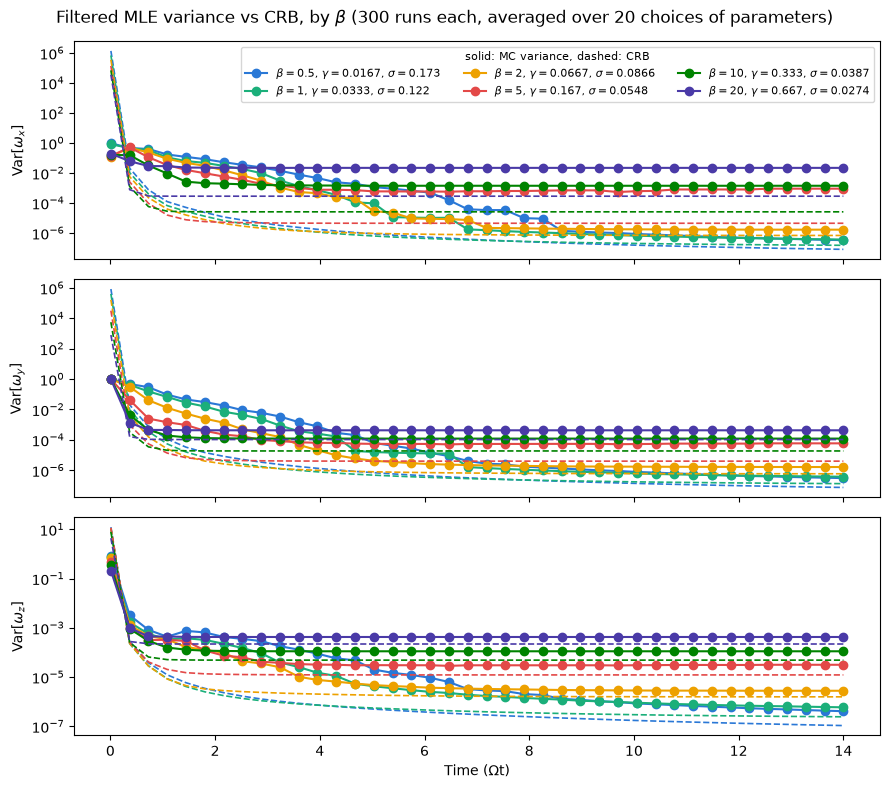

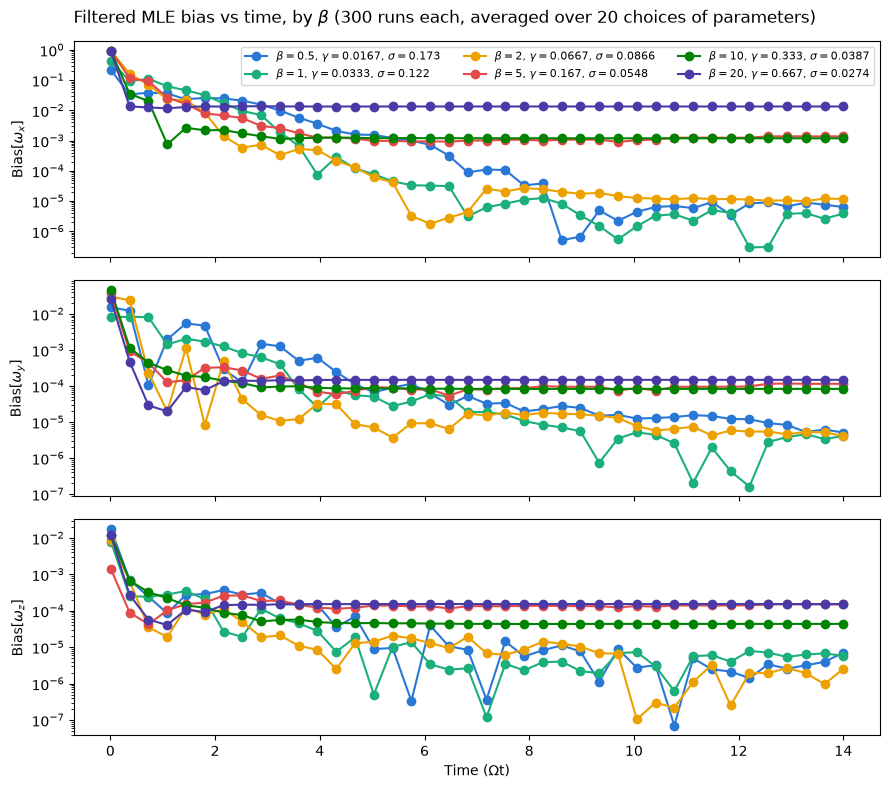

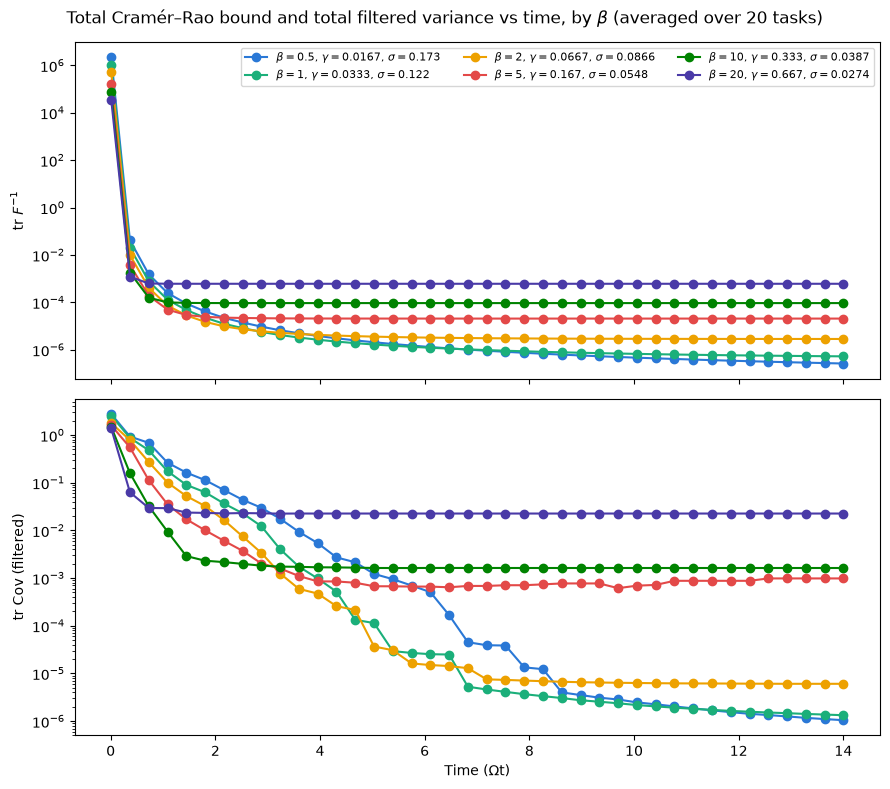

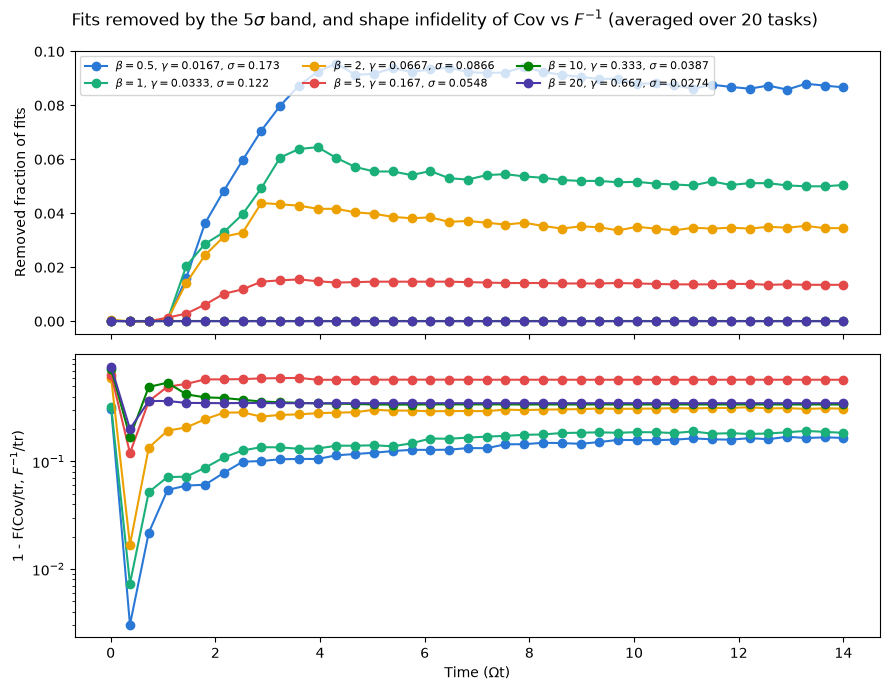

In [5]:
tasks = task_dirs()
runs = {p.name: load_npy(p) for p in tasks}
ref = runs[tasks[0].name]
beta_values = ref['beta_array']; gamma_values = ref['gamma_array']; checkpoint_times = ref['time_cutoffs_array']
for r in runs.values():
    assert np.array_equal(r['beta_array'], beta_values) and np.array_equal(r['time_cutoffs_array'], checkpoint_times)

per_task = {k: [] for k in ['bias_f', 'var_f', 'removed_f', 'crb', 'fisher_inv_trace', 'accept_fraction', 'infidelity', 'w_true']}
for name, r in runs.items():
    b, v, rem = filter_cost_band(r)
    per_task['bias_f'].append(b[0]); per_task['var_f'].append(v[0]); per_task['removed_f'].append(rem[0])
    per_task['crb'].append(crb_diag(r)[0])
    per_task['fisher_inv_trace'].append(r['fisher_inv_trace'][0])
    per_task['accept_fraction'].append(r['accept_fraction'][0])
    per_task['infidelity'].append(r['infidelity'][0])
    per_task['w_true'].append(r['w_true'][0])
per_task = {k: np.array(v) for k, v in per_task.items()}      # leading axis = task
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=RuntimeWarning)
    avg = {k: np.nanmean(v, axis=0) for k, v in per_task.items() if k != 'w_true'}
n_tasks = len(tasks)

print(f"{n_tasks} tasks; w_true spread (std over tasks):", np.round(per_task['w_true'].std(axis=0), 3))
print("worst accept fraction per task:", dict(zip(runs.keys(), np.round(per_task['accept_fraction'].min(axis=(1, 2)), 3).tolist())))

#Filtered variance averaged over tasks, with the task-averaged Cramer-Rao bound
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j, lab in enumerate(labels_omega):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, avg['var_f'][b_idx][:, j], 'o-', color=color, label=beta_label(ref, b_idx))
        axes[j].semilogy(checkpoint_times*dt, avg['crb'][b_idx][:, j], '--', color=color, lw=1.2)
    axes[j].set_ylabel(f'Var[{lab}]')
axes[0].legend(loc='upper right', ncol=3, fontsize=8, title='solid: MC variance, dashed: CRB', title_fontsize=8)
axes[-1].set_xlabel(r'Time ($\Omega$t)')
fig.suptitle(f'Filtered MLE variance vs CRB, by $\\beta$ ({n_fits} runs each, averaged over {n_tasks} choices of parameters)')
plt.tight_layout()
plt.show()

#Filtered bias averaged over tasks
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j, lab in enumerate(labels_omega):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, np.abs(avg['bias_f'][b_idx][:, j]), 'o-', color=color, label=beta_label(ref, b_idx))
    axes[j].set_ylabel(f'Bias[{lab}]')
axes[0].legend(loc='upper right', ncol=3, fontsize=8)
axes[-1].set_xlabel(r'Time ($\Omega$t)')
fig.suptitle(f'Filtered MLE bias vs time, by $\\beta$ ({n_fits} runs each, averaged over {n_tasks} choices of parameters)')
plt.tight_layout()
plt.show()

#Trace of the inverse Fisher information and the filtered total variance, averaged over tasks
fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)
for b_idx, beta in enumerate(beta_values):
    color = beta_colors[b_idx % len(beta_colors)]
    axes[0].semilogy(checkpoint_times*dt, avg['fisher_inv_trace'][b_idx], 'o-', color=color, label=beta_label(ref, b_idx))
    axes[1].semilogy(checkpoint_times*dt, avg['var_f'][b_idx].sum(axis=1), 'o-', color=color, label=beta_label(ref, b_idx))
axes[0].set_ylabel(r'tr $F^{-1}$')
axes[1].set_ylabel(r'tr Cov (filtered)')
axes[0].legend(loc='upper right', ncol=3, fontsize=8)
axes[-1].set_xlabel(r'Time ($\Omega$t)')
fig.suptitle(f'Total Cramér–Rao bound and total filtered variance vs time, by $\\beta$ (averaged over {n_tasks} tasks)')
plt.tight_layout()
plt.show()

#QA: removed fraction and infidelity between normalized Cov and F^-1
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
for b_idx, beta in enumerate(beta_values):
    color = beta_colors[b_idx % len(beta_colors)]
    axes[0].plot(checkpoint_times*dt, avg['removed_f'][b_idx], 'o-', color=color, label=beta_label(ref, b_idx))
    axes[1].semilogy(checkpoint_times*dt, avg['infidelity'][b_idx], 'o-', color=color, label=beta_label(ref, b_idx))
axes[0].set_ylabel('Removed fraction of fits')
axes[1].set_ylabel(r'1 - F(Cov/tr, $F^{-1}$/tr)')
axes[0].legend(loc='upper left', ncol=3, fontsize=8)
axes[-1].set_xlabel(r'Time ($\Omega$t)')
fig.suptitle(f'Fits removed by the $5\\sigma$ band, and shape infidelity of Cov vs $F^{{-1}}$ (averaged over {n_tasks} tasks)')
plt.tight_layout()
plt.show()


### How to read the dashed Cramér–Rao curves at strong probe

For $\beta\ge5$ the filtered Monte Carlo variance sits 20–50× above the dashed bound, while no fits
are rejected and the accepted fits lie exactly on the noise floor (mean excess cost $\approx 0$ in units
of the band width). So they are statistically as good as the truth: this is not optimizer failure, and
not a sign ambiguity either (only 1–3 % of fits are $\omega_x$ mirror solutions).

The reason is the bound's bookkeeping. `fisher.npy` is the realization-averaged Fisher matrix
$\mathbb{E}[F_i]$ and the dashed curves are $\mathrm{diag}\,[\mathbb{E}F_i]^{-1}$. Every realization has
its own random control phases and is fitted on its own, so the variance such a per-realization estimator
can reach, averaged over realizations, is bounded by $\mathbb{E}[F_i^{-1}] \ge [\mathbb{E}F_i]^{-1}$
(Jensen). With strong decoherence the information comes from a window of length $\sim 1/\gamma$ in which
the particular phases matter a lot (the per-realization bound spreads by a factor $\sim100$ across
realizations), and the two bounds differ by an order of magnitude. Recomputing $F_i$ for 40 random
controls at $T=14/\Omega$, $\eta=30$, $\mathrm{OD}=10$:

| $\beta$ | $\mathrm{tr}\,[\mathbb{E}F]^{-1}$ | $\mathrm{tr}\,\mathbb{E}[F^{-1}]$ | ratio |
|---|---|---|---|
| 2 | 3.2e-6 | 7.9e-6 | 2.4 |
| 5 | 2.0e-5 | 6.9e-5 | 3.5 |
| 20 | 6.0e-4 | 1.0e-2 | 17 |

Against $\mathbb{E}[F^{-1}]$ the $\beta=20$ Monte Carlo variance (2.2e-2) is within a factor 2. The
heavy tails in $\omega_x$ at $\beta\ge5$ are realizations whose control happened to carry little
$\omega_x$ information early on. This run did not save $F_i$ per realization; the v6 script now writes
`fisher_inv_realavg.npy` and `fisher_inv_realavg_trace.npy` ($\mathbb{E}[F_i^{-1}]$ and its trace) for
future runs, and Monte Carlo covariances should be compared against those. The ranking of $\beta$ by the
bound in the plots below is still the ranking of $[\mathbb{E}F]^{-1}$; by the reachable bound the
strong-probe advantage at short times is smaller than these curves suggest.


## Probe-strength trade-off: nonlinearity and decoherence against shot noise

Because $\gamma=\beta/\eta$ and $\sigma^2\propto 1/\beta$, sweeping $\beta$ trades nonlinearity and
decoherence against readout noise, and there is no decoherence-free $\beta=0$ to compare against.
The plots below read the task-averaged results along $\beta$ at fixed time, as a ratio to the best
$\beta$ at that time (the optimum sits at 1), and as the best $\beta$ versus time. The expected
optimum is finite for every $T$, $\beta_{\rm opt}\sim\eta/T$: information grows like $\beta T^3$
while $T\ll\eta/\beta$ and saturates like $\eta^3/\beta^2$ once $T\gg\eta/\beta$.


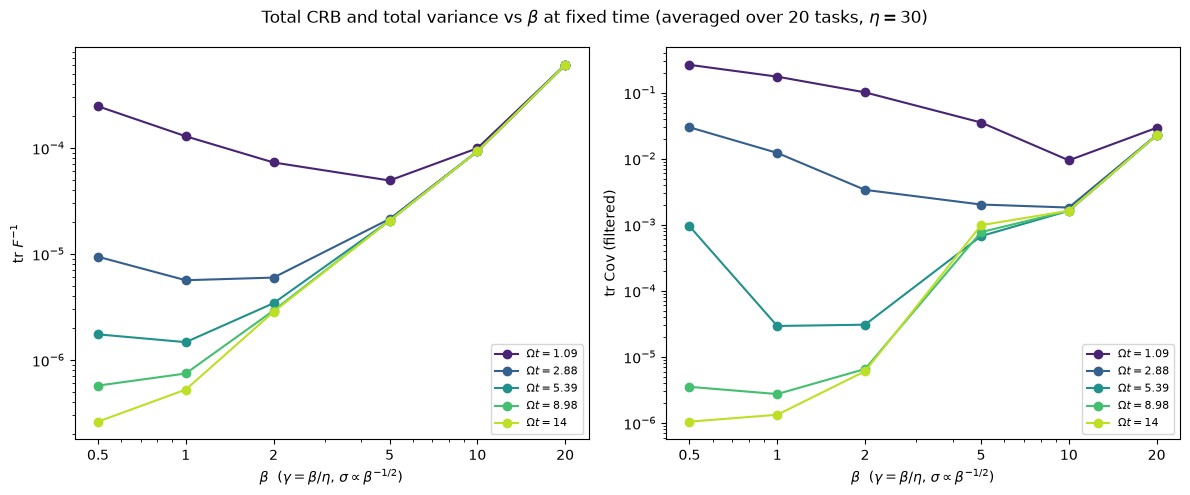

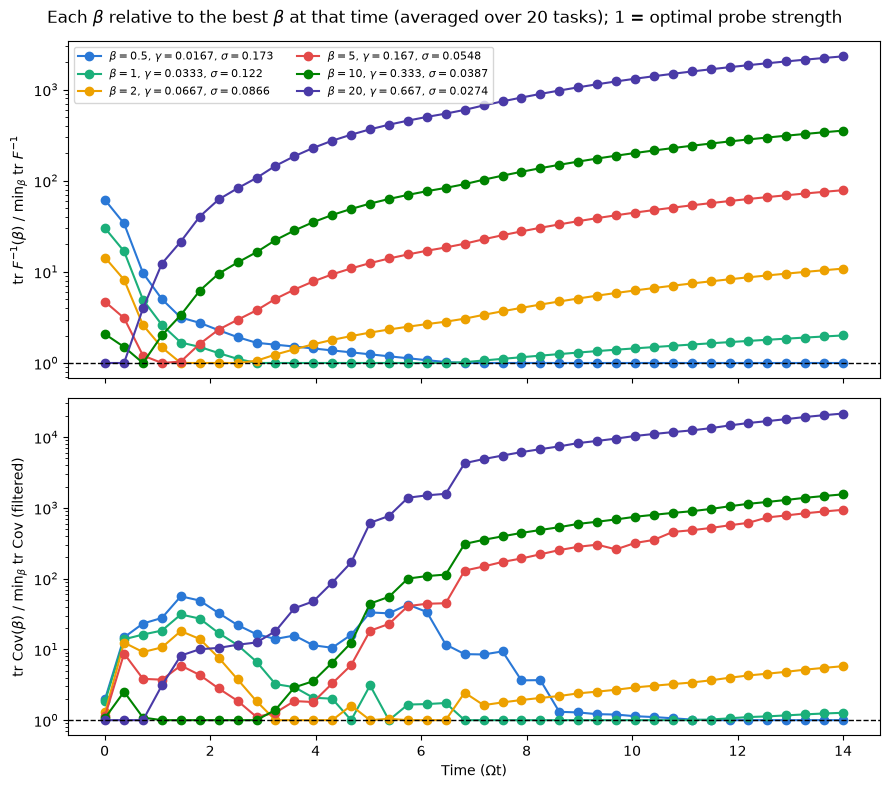

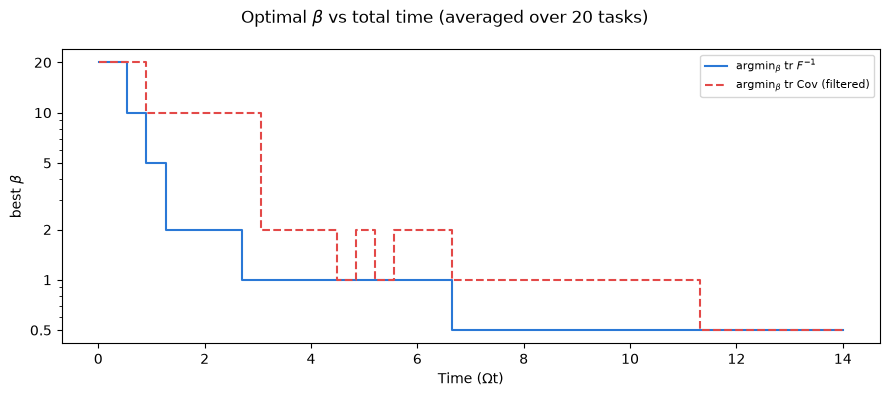

In [6]:
time_idx_show = [3, 8, 15, 25, len(checkpoint_times) - 1]
time_colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(time_idx_show)))

#Total CRB and total filtered variance as a function of beta at several fixed times
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
for c, ti in zip(time_colors, time_idx_show):
    axes[0].loglog(beta_values, avg['fisher_inv_trace'][:, ti], 'o-', color=c, label=fr'$\Omega t={checkpoint_times[ti]*dt:.3g}$')
    axes[1].loglog(beta_values, avg['var_f'][:, ti, :].sum(axis=1), 'o-', color=c, label=fr'$\Omega t={checkpoint_times[ti]*dt:.3g}$')
axes[0].set_ylabel(r'tr $F^{-1}$'); axes[1].set_ylabel('tr Cov (filtered)')
for ax in axes:
    ax.set_xlabel(r'$\beta$  ($\gamma=\beta/\eta$, $\sigma\propto\beta^{-1/2}$)')
    ax.set_xticks(beta_values); ax.set_xticklabels([f'{b:g}' for b in beta_values])
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
    ax.legend(fontsize=8)
fig.suptitle(f'Total CRB and total variance vs $\\beta$ at fixed time (averaged over {n_tasks} tasks, $\\eta={beta_values[1]/gamma_values[1]:.3g}$)')
plt.tight_layout()
plt.show()

#Ratio to the best beta at each time (there is no beta = 0 reference in the one-beam model)
fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)
crb_min = avg['fisher_inv_trace'].min(axis=0)
var_min = np.nanmin(avg['var_f'].sum(axis=2), axis=0)
for b_idx, beta in enumerate(beta_values):
    color = beta_colors[b_idx % len(beta_colors)]
    axes[0].semilogy(checkpoint_times*dt, avg['fisher_inv_trace'][b_idx]/crb_min, 'o-', color=color, label=beta_label(ref, b_idx))
    axes[1].semilogy(checkpoint_times*dt, avg['var_f'][b_idx].sum(axis=1)/var_min, 'o-', color=color, label=beta_label(ref, b_idx))
for ax in axes:
    ax.axhline(1.0, color='k', ls='--', lw=1)
axes[0].set_ylabel(r'tr $F^{-1}(\beta)$ / min$_\beta$ tr $F^{-1}$')
axes[1].set_ylabel(r'tr Cov$(\beta)$ / min$_\beta$ tr Cov (filtered)')
axes[0].legend(loc='upper left', ncol=2, fontsize=8)
axes[-1].set_xlabel(r'Time ($\Omega$t)')
fig.suptitle(f'Each $\\beta$ relative to the best $\\beta$ at that time (averaged over {n_tasks} tasks); 1 = optimal probe strength')
plt.tight_layout()
plt.show()

#Best beta at each cutoff, by CRB and by Monte Carlo variance
best_crb = beta_values[np.argmin(avg['fisher_inv_trace'], axis=0)]
best_var = beta_values[np.nanargmin(avg['var_f'].sum(axis=2), axis=0)]
fig, ax = plt.subplots(1, 1, figsize=(9, 4))
ax.step(checkpoint_times*dt, best_crb, where='mid', color=beta_colors[0], label=r'argmin$_\beta$ tr $F^{-1}$')
ax.step(checkpoint_times*dt, best_var, where='mid', color=beta_colors[3], ls='--', label=r'argmin$_\beta$ tr Cov (filtered)')
ax.set_yscale('log'); ax.set_yticks(beta_values); ax.set_yticklabels([f'{b:g}' for b in beta_values])
ax.yaxis.set_minor_formatter(plt.NullFormatter())
ax.set_ylabel(r'best $\beta$')
ax.set_xlabel(r'Time ($\Omega$t)')
ax.legend(loc='upper right', fontsize=8)
fig.suptitle(f'Optimal $\\beta$ vs total time (averaged over {n_tasks} tasks)')
plt.tight_layout()
plt.show()


## Time to reach a target precision versus $\beta$

The figure of merit for the protocol: for a target total variance, which $\beta$ gets there first?
For each $\beta$ the plotted time is the earliest cutoff after which the task-averaged curve stays
below the target for the rest of the run (log-interpolated between cutoffs), so early dips of the
still-unconverged fits are not counted. First table: Monte Carlo filtered variance. Second: Cramér–Rao
bound. A dash means the target is never reached within $T = 14/\Omega$, which is the decoherence
floor at that $\beta$; the fastest $\beta$ in each column is bold.


In [7]:
def time_to_target(curve, times, target):
    #Earliest time after which curve stays below target, log-interpolated; NaN if never within the run.
    above = curve > target
    if not above.any():
        return times[0]
    i = int(np.max(np.where(above)[0]))
    if i + 1 >= len(times):
        return np.nan
    f = (np.log(curve[i]) - np.log(target)) / (np.log(curve[i]) - np.log(curve[i + 1]))
    return times[i] + f * (times[i + 1] - times[i])

targets = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7]
times = checkpoint_times * dt
tot_var = avg['var_f'].sum(axis=2)            # (n_beta, n_time)
tot_crb = avg['fisher_inv_trace']             # (n_beta, n_time)

def time_table(curves, caption):
    rows = {f'β = {beta:g}, γ = {gamma:.3g}, σ = {sd:.3g}': [time_to_target(curves[b], times, tgt) for tgt in targets]
            for b, (beta, gamma, sd) in enumerate(zip(beta_values, gamma_values, ref['sn_sd_array']))}
    df = pd.DataFrame(rows, index=[f'{tgt:.0e}' for tgt in targets]).T
    df.columns.name = 'target'
    return (df.style.set_caption(caption)
              .format(lambda v: '—' if np.isnan(v) else f'{v:.2f}')
              .highlight_min(axis=0, props='font-weight:bold;'))

display(time_table(tot_var, f'Time (Ω t) after which the filtered Monte Carlo total variance tr Cov stays below the target '
                            f'(averaged over {n_tasks} tasks; — = not reached within T = {times[-1]:g}; bold = fastest β)'))
display(time_table(tot_crb, f'Time (Ω t) after which the Cramér–Rao bound tr F⁻¹ stays below the target '
                            f'(averaged over {n_tasks} tasks; — = not reached within T = {times[-1]:g}; bold = fastest β)'))


target,1e-02,1e-03,1e-04,1e-05,1e-06,1e-07
"β = 0.5, γ = 0.0167, σ = 0.173",3.56,5.32,6.61,8.33,—,—
"β = 1, γ = 0.0333, σ = 0.122",2.94,3.94,5.07,6.68,—,—
"β = 2, γ = 0.0667, σ = 0.0866",2.39,3.34,4.83,6.99,—,—
"β = 5, γ = 0.167, σ = 0.0548",1.81,3.74,—,—,—,—
"β = 10, γ = 0.333, σ = 0.0387",1.07,—,—,—,—,—
"β = 20, γ = 0.667, σ = 0.0274",—,—,—,—,—,—


target,1e-02,1e-03,1e-04,1e-05,1e-06,1e-07
"β = 0.5, γ = 0.0167, σ = 0.173",0.52,0.81,1.40,2.83,6.87,—
"β = 1, γ = 0.0333, σ = 0.122",0.45,0.70,1.18,2.35,7.00,—
"β = 2, γ = 0.0667, σ = 0.0866",0.37,0.63,1.02,2.14,—,—
"β = 5, γ = 0.167, σ = 0.0548",0.35,0.53,0.90,—,—,—
"β = 10, γ = 0.333, σ = 0.0387",0.33,0.45,1.08,—,—,—
"β = 20, γ = 0.667, σ = 0.0274",0.32,0.47,—,—,—,—
